Import Libraries

In [69]:
import jax
import flax
import optax
from jax import lax, random, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

# choose GPU
import os

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated


In [70]:
n_gpu = len(jax.devices())
jax.devices()

[CudaDevice(id=0)]

In [71]:
# For Google Collab
# DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/data/"

# For PC
DATA_DIR = Path.cwd().parent.parent.parent / "data"

In [72]:
DATA_FILE = DATA_DIR / "data_T20_S30_G50.dat"

dat = np.loadtxt(DATA_FILE, skiprows=1, delimiter=',') # data on CPU
print (dat.shape)

# swap header for non reduced dataset as it was not labelled properly
if DATA_FILE == DATA_DIR / "data_T20_S30_G50.dat":
    dat[:, [0, 1]] = dat[:, [1, 0]]

# crop to focus on area of interest in the grid
# dat = dat[(dat[:,1] > 150) & (dat[:,1] < 350)] # selects all rows where the y-coordinate falls strictly between 150 and 350

# Calculate dimensions
nx = len(np.unique(dat[:, 0])) # take every row in x col 
ny = len(np.unique(dat[:, 1])) # take every row in y col

print(dat.shape)
print(f"Grid dimensions: nx={nx}, ny={ny}")
print(np.unique(dat[:,0]).shape, np.unique(dat[:,1]).shape) # unique coordinate values along each individual axis

x_l, x_u, y_l, y_u = np.unique(dat[:,0]).min(), np.unique(dat[:,0]).max(), np.unique(dat[:,1]).min(), np.unique(dat[:,1]).max()
ext = [x_l, x_u, y_l, y_u] # plot boundary
print(ext)

(491520, 4)
(491520, 4)
Grid dimensions: nx=960, ny=512
(960,) (512,)
[np.float64(0.5), np.float64(959.5), np.float64(0.5), np.float64(511.5)]


Text(0.5, 1.0, 'Solution')

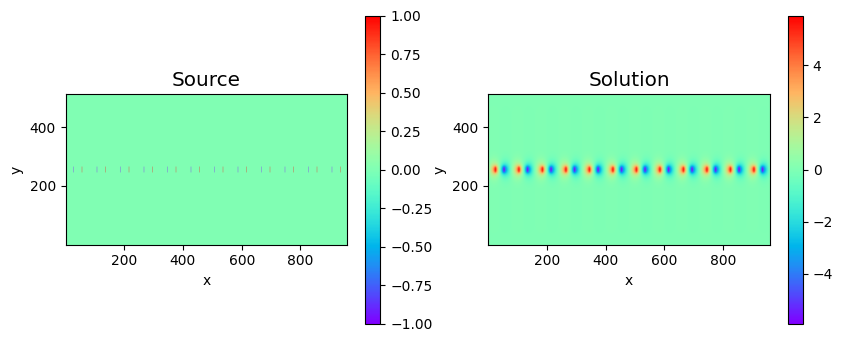

In [73]:
"""
Plot the system with boundaries as the perimeter of the plot
"""
# Source
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1,2,1)
s_plot = dat[:,2].reshape(nx, ny).T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y')
plt.title('Source', fontsize='x-large')

# Solution
ax1 = fig.add_subplot(1,2,2)
s_plot = dat[:,3].reshape(nx, ny).T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y')
plt.title('Solution', fontsize='x-large')

In [74]:
dat = jnp.array(dat) # data now on GPU
x, y, s, u_sim = dat[:,0].reshape(-1, 1), dat[:,1].reshape(-1, 1), dat[:,2].reshape(-1, 1), dat[:,3].reshape(-1, 1)

# Neumann Boundaries (Top and Bottom edges)
bc_n = ((y == y_l) | (y == y_u)).flatten()
print('Neumann BC: #sample = %d'%bc_n.sum())

# Boundary Conditions (bc), Periodic upper (pu) and Periodic  lower (pl)
bc_pl, bc_pu = ((x == x_l)).flatten(), ((x == x_u)).flatten()
print('Periodic BC: #sample = %d %d'%(bc_pl.sum(), bc_pu.sum()))

# bc_d = ((y == y_l) | (y == y_u) | (x == x_l) | (x == x_u)).flatten()
# print ('Dirichlet BC: #sample = %d'%bc_d.sum())

# Boundary points for mini-batching
x_n, y_n = x[bc_n], y[bc_n]
x_pl, y_pl = x[bc_pl], y[bc_pl]
x_pu, y_pu = x[bc_pu], y[bc_pu]

Neumann BC: #sample = 1920
Periodic BC: #sample = 512 512


FrPINN

In [75]:
# construct randomization B-PINN for linear/nonlinear ODE/PDEs
@jit
def get_f(x, y, weights):
    h1 = (x - 125.) / 100. * weights[0] + (y - 250.) / 100. * weights[1] + weights[2]
    h2 = (x - 125.) / 100. * weights[3] + (y - 250.) / 100. * weights[4] + weights[5]
    h3 = (x - 125.) / 100. * weights[6] + (y - 250.) / 100. * weights[7] + weights[8]
    h4 = (x - 125.) / 100. * weights[9] + (y - 250.) / 100. * weights[10] + weights[11]
    h5 = (x - 125.) / 100. * weights[12] + (y - 250.) / 100. * weights[13] + weights[14]
    h6 = (x - 125.) / 100. * weights[15] + (y - 250.) / 100. * weights[16] + weights[17]

    f = jnp.hstack([jnp.sin(h1), jnp.sin(1*jnp.pi*h1), jnp.sin(2*jnp.pi*h1), nn.softplus(h2), jnp.tanh(h3),
                    jnp.sin(h4), jnp.sin(1*jnp.pi*h4), jnp.sin(2*jnp.pi*h4), nn.softplus(h5), jnp.tanh(h6)])
    return f # 10 final features

# obtain f_dir
def get_f_dir(get_f, x, y, weights):
    f_x, f_y = jacfwd(get_f)(x, y, weights), jacfwd(get_f, argnums=1)(x, y, weights)
    f_xx, f_yy = jacfwd(jacfwd(get_f))(x, y, weights), jacfwd(jacfwd(get_f, argnums=1), argnums=1)(x, y, weights)
    return f_x, f_y, f_xx, f_yy

f_vmap = vmap(get_f, in_axes=(0, 0, None))
f_dir_vmap = vmap(get_f_dir, in_axes=(None, 0, 0, None))

In [76]:
# no. of neurons
n_node = 150

# generate weight & bias distribution
seed = 0
key, rng = random.split(random.PRNGKey(seed))
key, rng = random.split(rng)
weights_n = random.truncated_normal(key, shape=(n_node, 9), lower=-1, upper=1) # sampled from normal distribution
key, rng = random.split(rng)
weights_u = random.uniform(key, (n_node, 9), minval=-1, maxval=1) # sampled from uniform distribution

# regularization
lamb = 1e-4

In [77]:
# Pre-train hyper-parameters for nonlinear hidden layer weights

param = jnp.array([ 10.09822957,  -3.87555686, -16.929685  ,  -2.77833317,
                   -15.22937101, -17.93026106,   0.75740902,  -1.08731573,
                   -15.22055726,   0.20566555,   2.09818805,   1.31966254,
                    41.06236758, -24.7403773 , -67.06658613,   1.87400817,
                     0.53709715,  12.50666705, -12.6852006 , -13.75918575,
                    23.12318144, -13.35527196,   7.92822574,  -1.26146055,
                   -26.1894822 ,  -0.72503231,   0.09145113,  -0.32225884,
                     3.04884214,  18.73283007, -11.30517284,   8.23196755,
                   -31.6906244 ,   1.65942281, -21.71534774,  13.22925764,
                     0.27084133])

In [78]:
# """
# Build $A_{aug}$ on CPU
# """

# @jit
# def get_pde_chunk(x_c, y_c, weights):
#     f_xx, f_yy = f_dir_vmap(get_f, x_c, y_c, weights)[2:]
#     return (f_xx[:,:,0,0] + f_yy[:,:,0,0])

# @jit
# def get_bc_matrices(x_n, y_n, x_pl, y_pl, x_pu, y_pu, weights):
#     f_y = f_dir_vmap(get_f, x_n, y_n, weights)[1][:,:,0]
#     f_bc = f_vmap(x_pl, y_pl, weights) - f_vmap(x_pu, y_pu, weights)
#     return f_y, f_bc

# @jit
# def kaczmarz_step(A_B, b_B, w, alpha): 
#     block_size = A_B.shape[0]
#     r = A_B @ w - b_B
#     gram = A_B @ A_B.T + 1e-8 * jnp.eye(block_size)
#     z = jnp.linalg.solve(gram, r)
#     w_new = w - alpha * (A_B.T @ z)
#     return w_new

# # Main execution function (No @jit here so we can manage memory loops)
# def compute_ls_ntask_kazmarz_batched(param, key, epochs, block_size, alpha):
#     weights = jnp.hstack([weights_n* param[:9] + param[9:18], weights_u* param[18:27] + param[27:-1]]).T
#     reg = lamb * param[-1]

#     chunk_size = 10000
#     pde_list = []
    
#     # Build PDE directly into CPU RAM
#     for i in range(0, x.shape[0], chunk_size):
#         x_chunk = x[i:i+chunk_size]
#         y_chunk = y[i:i+chunk_size]
#         pde_chunk = get_pde_chunk(x_chunk, y_chunk, weights)
        
#         # transfer to cpu 
#         pde_list.append(np.array(pde_chunk))

#     # Stack chunks on the CPU
#     pde_cpu = np.vstack(pde_list) / 100.
#     pde_list.clear()

#     # Build BC matrices and transfer to CPU
#     fy_bc, f_bc = get_bc_matrices(x_n, y_n, x_pl, y_pl, x_pu, y_pu, weights)
#     fy_bc_cpu = np.array(fy_bc)
#     f_bc_cpu = np.array(f_bc)

#     n_bc_cpu = np.zeros((fy_bc_cpu.shape[0], 1))
#     p_bc_cpu = np.zeros((f_bc_cpu.shape[0], 1))

#     # Assemble system ON THE CPU
#     A_cpu = np.vstack([pde_cpu, fy_bc_cpu, f_bc_cpu])
#     b_cpu = np.vstack([np.array(s) / 100., n_bc_cpu, p_bc_cpu])

#     # Build augmented matrix ON THE CPU
#     m = A_cpu.shape[1]
#     lambda_I_cpu = np.sqrt(float(reg)) * np.eye(m)
#     A_aug_cpu = np.vstack([A_cpu, lambda_I_cpu])
#     b_aug_cpu = np.concatenate([b_cpu, np.zeros((m, 1))], axis=0)

#     n_aug = A_aug_cpu.shape[0]
    
#     # Clean up intermediate CPU matrices
#     del pde_cpu, fy_bc_cpu, f_bc_cpu, A_cpu, b_cpu, lambda_I_cpu
    
#     import gc
#     gc.collect()
#     jax.clear_caches() 

#     iters_per_epoch = n_aug // block_size
#     num_iterations = iters_per_epoch * epochs
    
#     w = jnp.zeros((m, 1))
    
#     for i in range(num_iterations):
#         # Slice the memory on the CPU (Takes ZERO GPU VRAM)
#         idx = np.random.choice(n_aug, size=block_size, replace=False)
#         A_B_cpu = A_aug_cpu[idx, :]
#         b_B_cpu = b_aug_cpu[idx]
        
#         # Send ONLY the tiny batch to the GPU
#         A_B = jnp.array(A_B_cpu)
#         b_B = jnp.array(b_B_cpu)
        
#         # Run the compiled math on the GPU
#         w = kaczmarz_step(A_B, b_B, w, alpha)
        
#         if i % 100 == 0:
#             w.block_until_ready()
            
#     w.block_until_ready() 
#     del A_aug_cpu, b_aug_cpu
    
#     # metrics chunked 
#     chunk_size = 10000
#     u_list = []
    
#     for i in range(0, x.shape[0], chunk_size):
#         x_c = x[i:i+chunk_size]
#         y_c = y[i:i+chunk_size]
        
#         f_chunk = f_vmap(x_c, y_c, weights)
        
#         u_chunk = f_chunk @ w
#         u_chunk.block_until_ready()
#         u_list.append(u_chunk)

#     u = jnp.vstack(u_list)
#     u_list.clear() # Free list memory
    
#     mse = jnp.mean((u_sim - u)**2)  
#     mae = jnp.mean(jnp.abs(u_sim - u))
#     rl2 = jnp.linalg.norm(u_sim - u) / jnp.linalg.norm(u_sim) 
    
#     return u, mse, mae, rl2

In [79]:
"""
Build Sub-matrices on CPU and perform Stratified Sampling
"""

@jit
def get_pde_chunk(x_c, y_c, weights):
    f_xx, f_yy = f_dir_vmap(get_f, x_c, y_c, weights)[2:]
    return (f_xx[:,:,0,0] + f_yy[:,:,0,0])

@jit
def get_bc_matrices(x_n, y_n, x_pl, y_pl, x_pu, y_pu, weights):
    f_y = f_dir_vmap(get_f, x_n, y_n, weights)[1][:,:,0]
    f_bc = f_vmap(x_pl, y_pl, weights) - f_vmap(x_pu, y_pu, weights)
    return f_y, f_bc

@jit
def kaczmarz_step(A_B, b_B, w, alpha): 
    block_size = A_B.shape[0]
    r = A_B @ w - b_B
    gram = A_B @ A_B.T + 1e-8 * jnp.eye(block_size)
    z = jnp.linalg.solve(gram, r)
    w_new = w - alpha * (A_B.T @ z)
    return w_new

# Main execution function (No @jit here so we can manage memory loops)
def compute_ls_ntask_kazmarz_batched(param, key, epochs, block_size, alpha):
    weights = jnp.hstack([weights_n* param[:9] + param[9:18], weights_u* param[18:27] + param[27:-1]]).T
    reg = lamb * param[-1]

    chunk_size = 10000
    pde_list = []
    
    # Build PDE directly into CPU RAM
    for i in range(0, x.shape[0], chunk_size):
        x_chunk = x[i:i+chunk_size]
        y_chunk = y[i:i+chunk_size]
        pde_chunk = get_pde_chunk(x_chunk, y_chunk, weights)
        
        # transfer to cpu 
        pde_list.append(np.array(pde_chunk))

    # Stack chunks on the CPU
    pde_cpu = np.vstack(pde_list) / 100.
    pde_list.clear()

    # Build BC matrices and transfer to CPU
    fy_bc, f_bc = get_bc_matrices(x_n, y_n, x_pl, y_pl, x_pu, y_pu, weights)
    fy_bc_cpu = np.array(fy_bc)
    f_bc_cpu = np.array(f_bc)

    # Target vector for PDE (using global 's' as in original code)
    b_pde_cpu = np.array(s) / 100.

    # L2 Regularization matrix
    m = pde_cpu.shape[1]
    lambda_I_cpu = np.sqrt(float(reg)) * np.eye(m)

    # ----- STRATIFIED SAMPLING SETUP -----
    # Number of available rows for each component
    n_pde = pde_cpu.shape[0]
    n_nbc = fy_bc_cpu.shape[0]
    n_pbc = f_bc_cpu.shape[0]
    n_reg = lambda_I_cpu.shape[0]

    # Calculate stratified batch sizes based on your notes (70% PDE, 10% Neumann, 10% Periodic, 10% Reg)
    s_pde = int(block_size * 0.70)
    s_nbc = int(block_size * 0.10)
    s_pbc = int(block_size * 0.10)
    s_reg = block_size - s_pde - s_nbc - s_pbc # Remainder ensures it sums exactly to block_size

    n_total = n_pde + n_nbc + n_pbc + n_reg
    
    # Clean up memory caches
    import gc
    gc.collect()
    jax.clear_caches() 

    iters_per_epoch = n_total // block_size
    num_iterations = iters_per_epoch * epochs
    
    w = jnp.zeros((m, 1))
    
    for i in range(num_iterations):
        # Stratified Sampling with replacement ON THE CPU
        idx_pde = np.random.choice(n_pde, size=s_pde, replace=True)
        idx_nbc = np.random.choice(n_nbc, size=s_nbc, replace=True)
        idx_pbc = np.random.choice(n_pbc, size=s_pbc, replace=True)
        idx_reg = np.random.choice(n_reg, size=s_reg, replace=True)

        # Assemble the mini-batch matrix dynamically
        A_B_cpu = np.vstack([
            pde_cpu[idx_pde, :],
            fy_bc_cpu[idx_nbc, :],
            f_bc_cpu[idx_pbc, :],
            lambda_I_cpu[idx_reg, :]
        ])
        
        # Assemble target mini-batch vector dynamically (BCs and Reg target exactly 0)
        b_B_cpu = np.vstack([
            b_pde_cpu[idx_pde],
            np.zeros((s_nbc, 1)),
            np.zeros((s_pbc, 1)),
            np.zeros((s_reg, 1))
        ])
        
        # Send ONLY the tiny batch to the GPU
        A_B = jnp.array(A_B_cpu)
        b_B = jnp.array(b_B_cpu)
        
        # Run the compiled math on the GPU
        w = kaczmarz_step(A_B, b_B, w, alpha)
        
        if i % 100 == 0:
            w.block_until_ready()
            
    w.block_until_ready() 
    
    # Free components
    del pde_cpu, fy_bc_cpu, f_bc_cpu, lambda_I_cpu
    
    # metrics chunked 
    chunk_size = 10000
    u_list = []
    
    for i in range(0, x.shape[0], chunk_size):
        x_c = x[i:i+chunk_size]
        y_c = y[i:i+chunk_size]
        
        f_chunk = f_vmap(x_c, y_c, weights)
        
        u_chunk = f_chunk @ w
        u_chunk.block_until_ready()
        u_list.append(u_chunk)

    u = jnp.vstack(u_list)
    u_list.clear() # Free list memory
    
    mse = jnp.mean((u_sim - u)**2)  
    mae = jnp.mean(jnp.abs(u_sim - u))
    rl2 = jnp.linalg.norm(u_sim - u) / jnp.linalg.norm(u_sim) 
    
    return u, mse, mae, rl2

In [ ]:
# solve problem
epochs = 500
block_size = 500 # set based on GPU VRAM limits
alpha = 0.001 # learning rate

key, rng = random.split(rng)
u, mse, mae, rl2 = compute_ls_ntask_kazmarz_batched(param, key, epochs, block_size, alpha) # hard coded for block = 500
print('MSE = %.2e  MAE = %.2e  RL2 = %.2e'%(mse, mae, rl2));

# plot solution
fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_subplot(1,3,1)
s_plot = s.reshape(nx, ny).T 
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); plt.title('Source', fontsize='x-large')
ax1 = fig.add_subplot(1,3,2)
s_plot = u_sim.reshape(nx, ny).T 
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); plt.title('Simulation', fontsize='x-large')
ax1 = fig.add_subplot(1,3,3)
s_plot = u.reshape(nx, ny).T  
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); plt.title('PINN', fontsize='x-large')

Time the run

In [ ]:
# _ = compute_ls_ntask_kazmarz_batched(param, key)

In [ ]:
#%%timeit -n 10 -r 2
#u, mse, rl2, mae = compute_ls_ntask_kazmarz_batched(param, key)
#u.block_until_ready()